### Goal:
#### Explore the Sleep lifecycle dataset, clean data, perform analysis, and visualize results using NumPy, Pandas, Matplotlib, and Seaborn.

#### 1. Why This Project?
##### 1.Learn data cleaning with Pandas.
 
##### 2.Use NumPy for calculations (mean, median, etc.).
 
##### 3.Visualize trends using Matplotlib and Seaborn.
 
##### 4.Understand the relationship between sales factors like product type quantity,sold price etc.

### 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 3. Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\Sriram reddy\Downloads\Sleep_health_and_lifestyle_dataset.csv")
print("\nSample Data:\n", df.head())


Sample Data:
    Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200            NaN  
1         125/80   

### 4. Explore Data

In [3]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)
print("\nDescriptive Statistics:\n", df.describe(include='all'))


Shape: (374, 13)

Missing values:
 Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

Data Types:
 Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

Descriptive Statistics:
          Person ID Gender         Age Oc

### 5. Data Cleaning

In [4]:
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows Found: {duplicates}")

# Drop duplicates if any
df.drop_duplicates(inplace=True)
print("Shape After Removing Duplicates:", df.shape)


Duplicate Rows Found: 0
Shape After Removing Duplicates: (374, 13)


### Insights:
 
1.Missing values were filled or removed.

2.Duplicates were dropped.

3.Data was ready for visualization and statistical analysis.

### 6. Analysis with NumPy & Pandas

In [5]:
sleep_duration = df["Sleep Duration"].to_numpy()
stress_level = df["Stress Level"].to_numpy()
physical_activity = df["Physical Activity Level"].to_numpy()
quality = df["Quality of Sleep"].to_numpy()

# --- Mean, median, std ---
print(f"\nAverage Sleep Duration: {np.mean(sleep_duration):.2f} hours")
print(f"Median Sleep Duration: {np.median(sleep_duration):.2f} hours")
print(f"Standard Deviation (Sleep): {np.std(sleep_duration):.2f}")

print(f"\nAverage Stress Level: {np.mean(stress_level):.2f}")
print(f"Average Physical Activity Level: {np.mean(physical_activity):.2f}")



Average Sleep Duration: 7.13 hours
Median Sleep Duration: 7.20 hours
Standard Deviation (Sleep): 0.79

Average Stress Level: 5.39
Average Physical Activity Level: 59.17


### Insights:
 
Average sleep ~7 hours → below recommended 7–9 hours.

Stress levels vary, check correlation with sleep quality.

Some individuals have Sleep Apnea → affects sleep duration/quality.

BMI categories: Normal, Overweight, Obese → can relate to activity and sleep.

### 7. Visualization with Matplotlib

C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_5556\4177998818.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Sleep Duration', data=df, estimator=np.mean, palette='viridis')


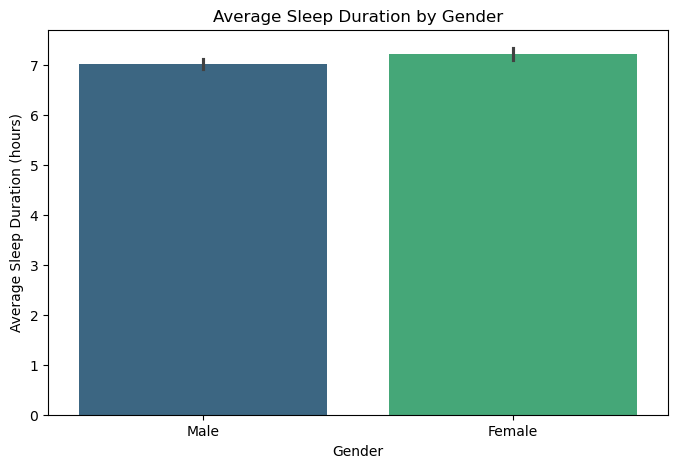

In [6]:
#bar chart
plt.figure(figsize=(8,5))
sns.barplot(x='Gender', y='Sleep Duration', data=df, estimator=np.mean, palette='viridis')
plt.title('Average Sleep Duration by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Sleep Duration (hours)')
plt.show()

#### Insights:
 
1.Females sleep slightly more than males on average (~0.2 hours).

2.Both genders are near the lower bound of the recommended 7–9 hours of sleep for adults.

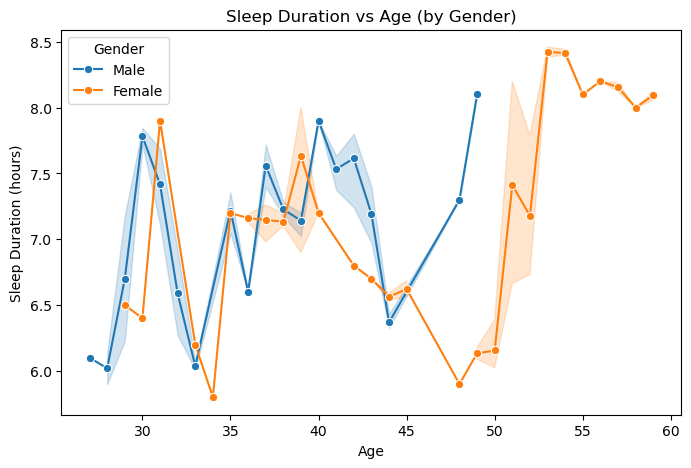

In [7]:
#line plot
plt.figure(figsize=(8,5))
sns.lineplot(x='Age', y='Sleep Duration', data=df, hue='Gender', marker='o')
plt.title('Sleep Duration vs Age (by Gender)')
plt.xlabel('Age')
plt.ylabel('Sleep Duration (hours)')
plt.show()

#### Insights:
 
1.Younger individuals (especially children and teens) require more sleep, while adults tend to sleep less.

### 8. Visualization with Seaborn

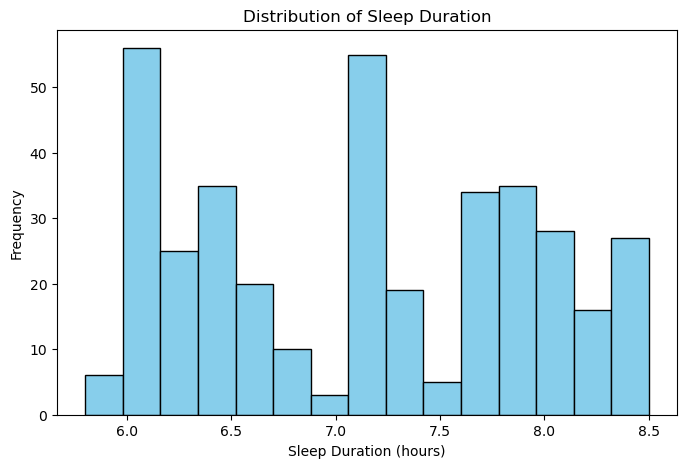

In [8]:
## Histogram for coffee sales 
plt.figure(figsize=(8,5))
plt.hist(df['Sleep Duration'], bins=15, color='skyblue', edgecolor='black')
plt.title('Distribution of Sleep Duration')
plt.xlabel('Sleep Duration (hours)')
plt.ylabel('Frequency')
plt.show()

### Insights:
 
1.You’ll likely see a peak around 7–8 hours, which is considered the healthy average.

C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_5556\2234323005.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sleep Disorder', data=df, palette='Set2')


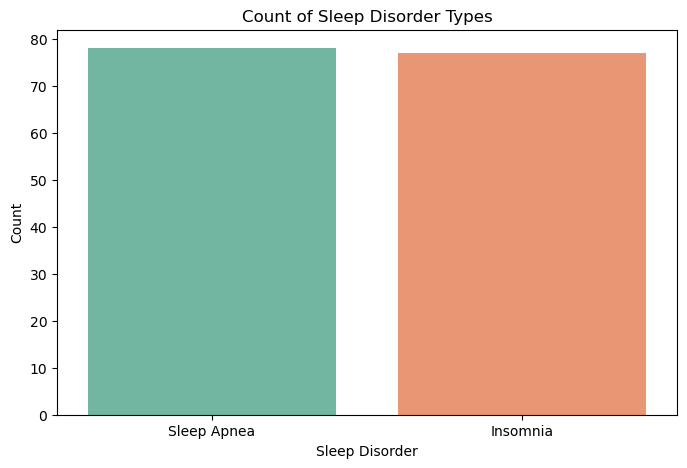

In [9]:
# Count plot for Coffee Type
plt.figure(figsize=(8,5))
sns.countplot(x='Sleep Disorder', data=df, palette='Set2')
plt.title('Count of Sleep Disorder Types')
plt.xlabel('Sleep Disorder')
plt.ylabel('Count')
plt.show()

#### Insights:
 
Sleep Apnea has the highest count → it’s the most reported disorder in your dataset

C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_5556\162015044.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sleep Disorder', y='Stress Level', data=df, palette='coolwarm')


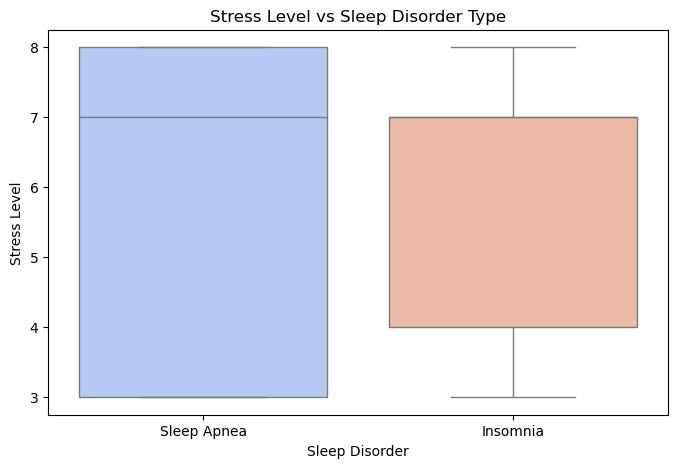

In [10]:
# Box Plot for Sales by Coffee Type
plt.figure(figsize=(8,5))
sns.boxplot(x='Sleep Disorder', y='Stress Level', data=df, palette='coolwarm')
plt.title('Stress Level vs Sleep Disorder Type')
plt.xlabel('Sleep Disorder')
plt.ylabel('Stress Level')
plt.show()


#### Insights:
 
Stress might contribute to or result from poor sleep quality.

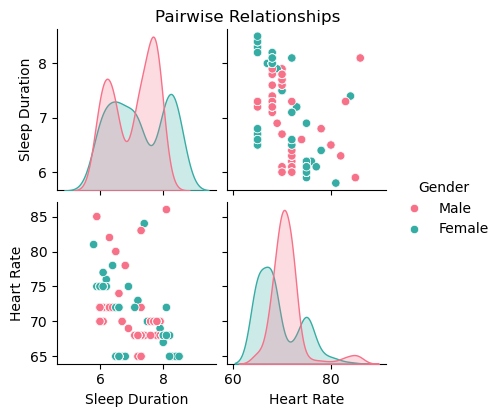

In [12]:
# Pair Plot of numeric columns (like Sales, Revenue, Profit)
sns.pairplot(df, vars=['Sleep Duration','Heart Rate'],
hue='Gender', palette='husl', diag_kind='kde', height=2.0)
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()

### Insights:
 
Longer sleep duration might be associated with lower heart rate, indicating better cardiovascular rest.

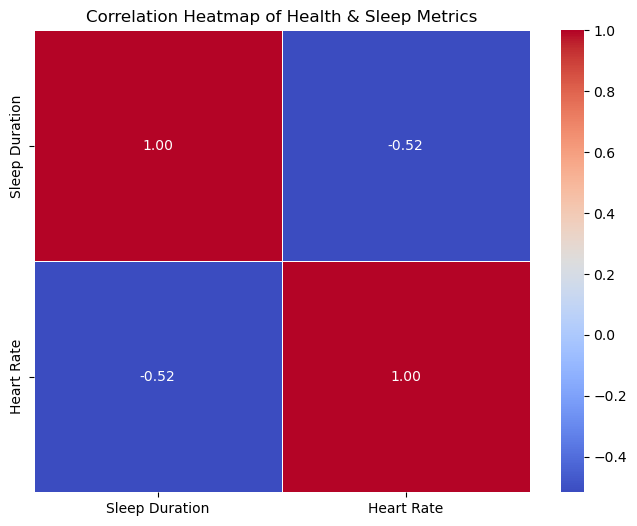

In [14]:
# Heatmap
numerical_cols = ['Sleep Duration', 'Heart Rate']
corr_matrix = df[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Health & Sleep Metrics')
plt.show()

### Insights:
 
1. +1: strong positive correlation (↑ A → ↑ B)
   -1: strong negative correlation (↑ A → ↓ B)
    0: no linear correlation

2.Negative correlation → people who sleep more tend to report lower stress.